# Example B: Optical Waveguides (variant with B.C.s)

In [1]:
# !pip install git+https://github.com/sichinaga/PyDMD@sparse-mode-bopdmd-FINAL

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from tqdm import tqdm

from pydmd import BOPDMD, SparseBOPDMD
from pydmd.plotter import plot_summary
from pydmd.sbopdmd_utils import *

def error(actual, truth):
    """
    Compute relative error.
    """
    return np.linalg.norm(actual - truth) / np.linalg.norm(truth)

import warnings
warnings.filterwarnings("ignore")

## Part 1: Define the eigenfunctions and eigenvalues
$$
\tfrac{1}{2} v_j''(x) - n_0(x) v_j(x) = \lambda_j v_j(x)
$$
$$
v_j(x_0) = v_j(x_{n+1}) = 0 \quad \text{(Dirichlet B.C.s)}
$$
$$
n_0(x) = 
\begin{cases}
-1 & |x| < 5 \\ 
\:\;\; 0 & \text{else}
\end{cases}
$$

In [2]:
from scipy import sparse
from scipy.ndimage import gaussian_filter1d

def n_0(x, V0=1, a=5):
    """
    The index of refraction profile.
    """
    n0_array = np.zeros(len(x))
    n0_array[np.abs(x) < a] = -V0

    return n0_array

def build_A(x):
    """
    Linear operator for ddx computations.
    """
    nx = len(x)
    dx = x[1] - x[0]
    A = np.diag(-2 * np.ones(nx))
    A += np.diag(np.ones(nx - 1), k=1)
    A += np.diag(np.ones(nx - 1), k=-1)
    A *= 1 / (2 * (dx ** 2))
    return A

Space Discretization: [-15.0, 15.0], dx = 0.03


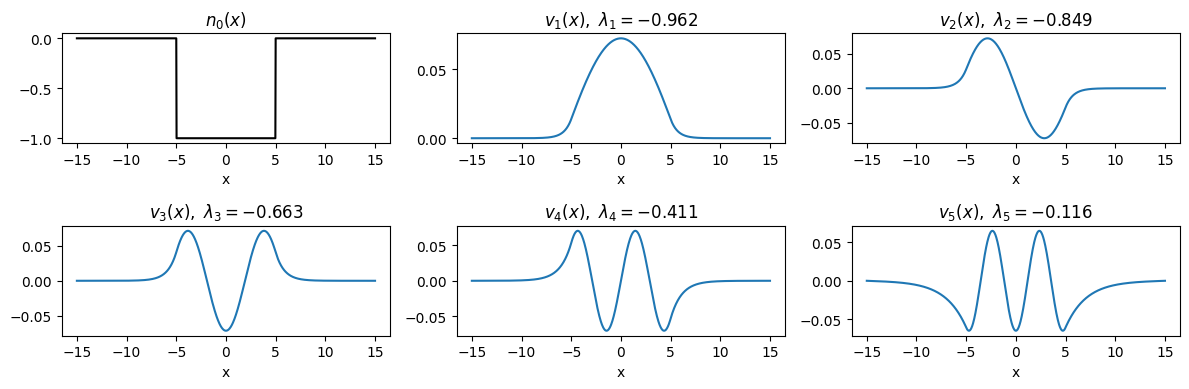

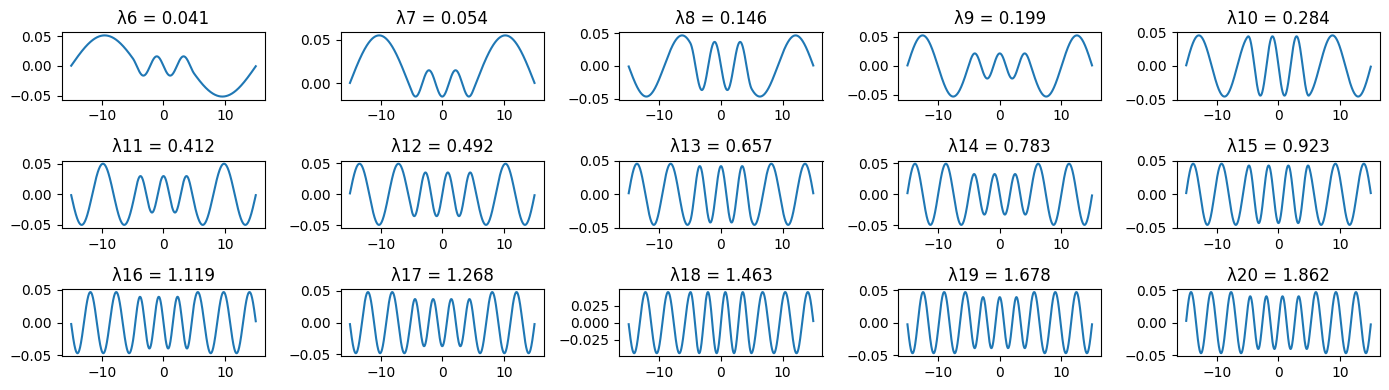

In [3]:
# Define the spatial grid (for computing ground truth spectrum).
nx = 1000
x = np.linspace(-15, 15, nx)
dx = x[1] - x[0]
print(f"Space Discretization: [{x[0]}, {x[-1]}], dx = {np.round(dx, decimals=3)}")

# Compute the index of refraction profile.
n0 = n_0(x)

# Define the operator that accounts for v_xx.
Av = build_A(x)

# Define the operator that accounts for n_0v.
Dv = -np.diag(n0)

# Build the linear operator for the eigenvalue problem.
Lv = sparse.dia_array(Av + Dv)

# Compute the first N eigenvalues and eigenvectors.
# Note: L is a symmetric matrix -- use eigsh.
N = nx - 1
eigs_true, V = sparse.linalg.eigsh(Lv, k=N, which="SM")

# Reverse the eigenfunction order.
eigs_true = np.flip(eigs_true)
V = np.flip(V, axis=1)

# Plot index of refraction and the bound eigenfunctions.
plt.figure(figsize=(12, 4))
plt.subplot(2, 3, 1)
plt.plot(x, n0, c="k")
plt.title("$n_0(x)$")
plt.xlabel("x")
for i, (v, _lambda) in enumerate(zip(V.T[:5], eigs_true[:5])):
    plt.subplot(2, 3, i + 2)
    plt.plot(x, v)
    plt.title(f"$v_{i+1}(x),$ $\lambda_{i+1} = {-np.round(_lambda, decimals=3)}$")
    plt.xlabel("x")
plt.tight_layout()
plt.show()

# Plot the next 15 modes (NOT localized to the well).
plt.figure(figsize=(14, 4))
for i, (v, _lambda) in enumerate(zip(V.T[5:20], eigs_true[5:20])):
    plt.subplot(3, 5, i + 1)
    plt.plot(x, v)
    plt.title(f"λ{i+6} = {-np.round(_lambda, decimals=3)}")
plt.tight_layout()
plt.show()

### Figure creation code:

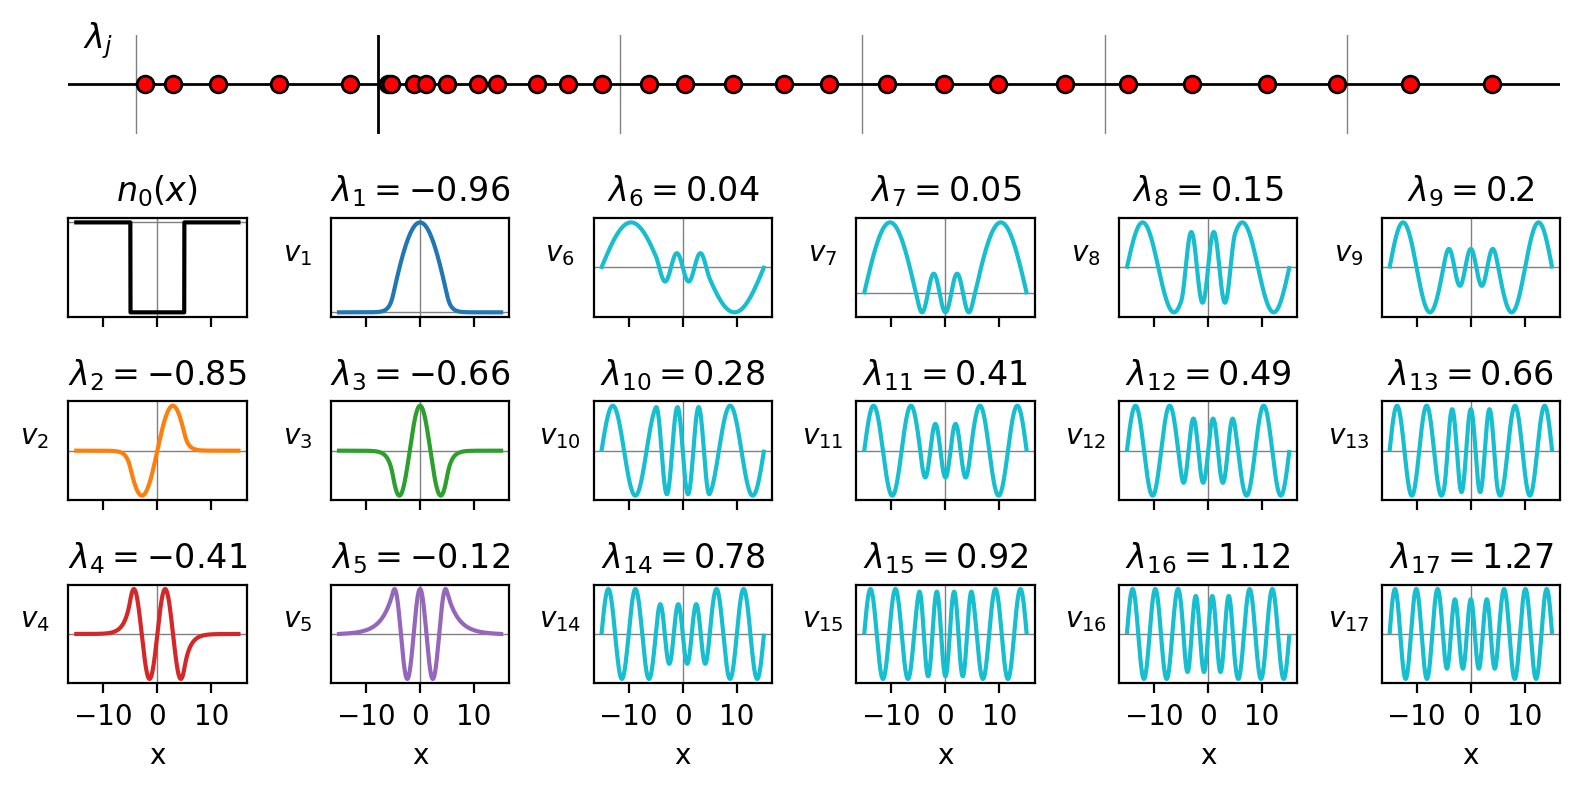

In [4]:
def flip_mode_signs(modes):
    """
    Flip the signs of the modes (for plotting) so that
    mode values start by increasing as x increases.
    """
    for i, v in enumerate(modes.T):
        diffs = v[1:] - v[:-1]
        large_diffs = diffs[np.abs(diffs) > 1e-10]
        if len(large_diffs) > 0 and large_diffs[0] < 0:
            modes[:, i] *= -1

    return modes

# Flip mode signs for figure consistency.
V = flip_mode_signs(V)
idx_flip = [1, 2]
V[:, idx_flip] = -V[:, idx_flip]

local_colors = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:cyan", # color for global modes
]

fig = plt.figure(figsize=(8, 4), dpi=200)
ax_eig = fig.add_subplot(4, 1, 1)
axes_modes = [fig.add_subplot(4, 6, i + 7) for i in range(18)]

# axes_modes indices for local modes:
idx_local = [1, 6, 7, 12, 13]
# axes_modes indices for global modes:
idx_global = [2, 3, 4, 5, 8, 9, 10, 11, 14, 15, 16, 17]

# Plot eigenvalues.
for xk in np.arange(-1, 5):
    ax_eig.axvline(x=xk, c="gray", lw=0.5)
ax_eig.axhline(y=0, c="k", lw=1)
ax_eig.axvline(x=0, c="k", lw=1)
ax_eig.plot(-eigs_true[:30].real, eigs_true[:30].imag, "o", c="r", mec="k")
ax_eig.axis("off")
ax_eig.set_title("$\lambda_j$", x=0.02, y=0.7)

# Plot index of refraction.
axes_modes[0].axhline(y=0, c="gray", lw=0.5)
axes_modes[0].axvline(x=0, c="gray", lw=0.5)
axes_modes[0].plot(x, n0, c="k")

axes_modes[0].set_title("$n_0(x)$")
axes_modes[0].set_yticks([])
axes_modes[0].set_xticklabels([])

# Plot bound eigenfunctions.
for i, (v, _lambda) in enumerate(zip(V.T[:5], eigs_true[:5])):
    ax = axes_modes[idx_local[i]]
    ax.axhline(y=0, c="gray", lw=0.5)
    ax.axvline(x=0, c="gray", lw=0.5)
    ax.plot(x, v, c=local_colors[i])
    ax.set_ylabel(f"$v_{i+1}$", rotation=0, labelpad=12)

    ax.set_title(f"$\lambda_{i+1} = {-np.round(_lambda, decimals=2)}$")
    ax.set_yticks([])
    if i > 2:
        ax.set_xlabel("x")
    else:
        ax.set_xticklabels([])

# Plot global eigenfunctions.
for i, (v, _lambda) in enumerate(zip(V.T[5:5+len(idx_global)], eigs_true[5:5+len(idx_global)])):
    ax = axes_modes[idx_global[i]]
    ax.axhline(y=0, c="gray", lw=0.5)
    ax.axvline(x=0, c="gray", lw=0.5)
    ax.plot(x, v, c=local_colors[-1])
    ax.set_ylabel("$v_{" + str(i+6) + "}$", rotation=0, labelpad=12)

    ax.set_title("$\lambda_{" + str(i+6) + "} = " + str(-np.round(_lambda, decimals=2)) + "$")
    ax.set_yticks([])
    if i > 7:
        ax.set_xlabel("x")
    else:
        ax.set_xticklabels([])

plt.tight_layout()
plt.show()

## Part 2: Build data set
$$
iu_t + \tfrac{1}{2}u_{xx} - n_0(x) u = 0
$$
$$
u(x_0, t) = u(x_{n+1}, t) = 0 \quad \text{(Dirichlet B.C.s)}
$$

In [5]:
# Define the temporal grid.
nt = 10000
t = np.linspace(0, 100, nt)
dt = t[1] - t[0]
print(f"Time Discretization: [{t[0]}, {t[-1]}], dt = {np.round(dt, decimals=3)}")

# Define the operator that accounts for u_xx.
Au = 1j * np.array(build_A(x), dtype="complex")

# Define the operator that accounts for n_0u.
Du = -1j * np.array(np.diag(n_0(x)), dtype="complex")

Time Discretization: [0.0, 100.0], dt = 0.01


### Define the data initial condition

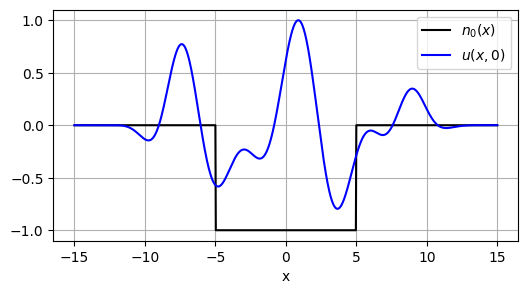

In [6]:
def generate_ic(num_freq, frequencies=None, seed=None):
    """
    Helper function for generating multi-scale initial conditions.
    """
    # If frequencies aren't given, generate random ones.
    if frequencies is None:
        rng = np.random.default_rng(seed)
        frequencies = rng.uniform(low=0.5, high=1.5, size=num_freq)
        return_freq = True
    else:
        return_freq = False

    # Smoothing function for enforcing boundary conditions.
    smoothing = np.zeros(nx)
    smoothing[200:-200] = 1.0
    smoothing = gaussian_filter1d(smoothing, sigma=50)

    # Initial condition is a mixture of sine and cosine waves.
    U0 = np.zeros(nx, dtype="complex")
    for i, f in enumerate(frequencies):
        if i % 2 == 0:
            U0 += np.sin(f * x)
        else:
            U0 += np.cos(f * x)

    # Smooth and normalize the initial condition.
    U0 = np.multiply(U0, smoothing)
    U0 /= np.abs(U0).max()

    # Don't return frequencies if they were given.
    if return_freq:
        return U0, frequencies

    return U0

# Use 10 random frequencies to generate an initial condition:
U0, frequencies = generate_ic(num_freq=10, seed=1234)

# Plot the initial condition.
plt.figure(figsize=(6, 3))
plt.plot(x, n0, c="k", label="$n_0(x)$")
plt.plot(x, U0, c="b", label="$u(x, 0)$")
plt.xlabel("x")
plt.legend()
plt.grid()
plt.show()

### Simulate forward in time OR load previous simulation

In [ ]:
# Propagate the system forward in time.
U = np.empty((nx, nt), dtype="complex")
U[:, 0] = U0
I = np.eye(nx)

for i in tqdm(range(nt - 1)):
    # Compute the linear operators L where U'(t) = L(t) U(t).
    Lu = Au + Du
    # Perform trapezoid discretization.
    Ai = sparse.csr_array(I - ((dt / 2) * Lu))
    bi = (I + ((dt / 2) * Lu)).dot(U[:, i])
    U[:, i+1] = sparse.linalg.spsolve(Ai, bi)

print("Data successfully generated!")
print(f"Data dimensions in (space, time): {U.shape}")

# Save the data:
np.save("data/waveguides/U.npy", U)

100%|██████████| 9999/9999 [02:54<00:00, 57.41it/s]

Data successfully generated!
Data dimensions in (space, time): (1000, 10000)


In [7]:
# Load previously generated data:
U = np.load("data/waveguides/U.npy")
print("Data successfully loaded!")
print(f"Data dimensions in (space, time): {U.shape}")

Data successfully loaded!
Data dimensions in (space, time): (1000, 10000)


### Visualize the data

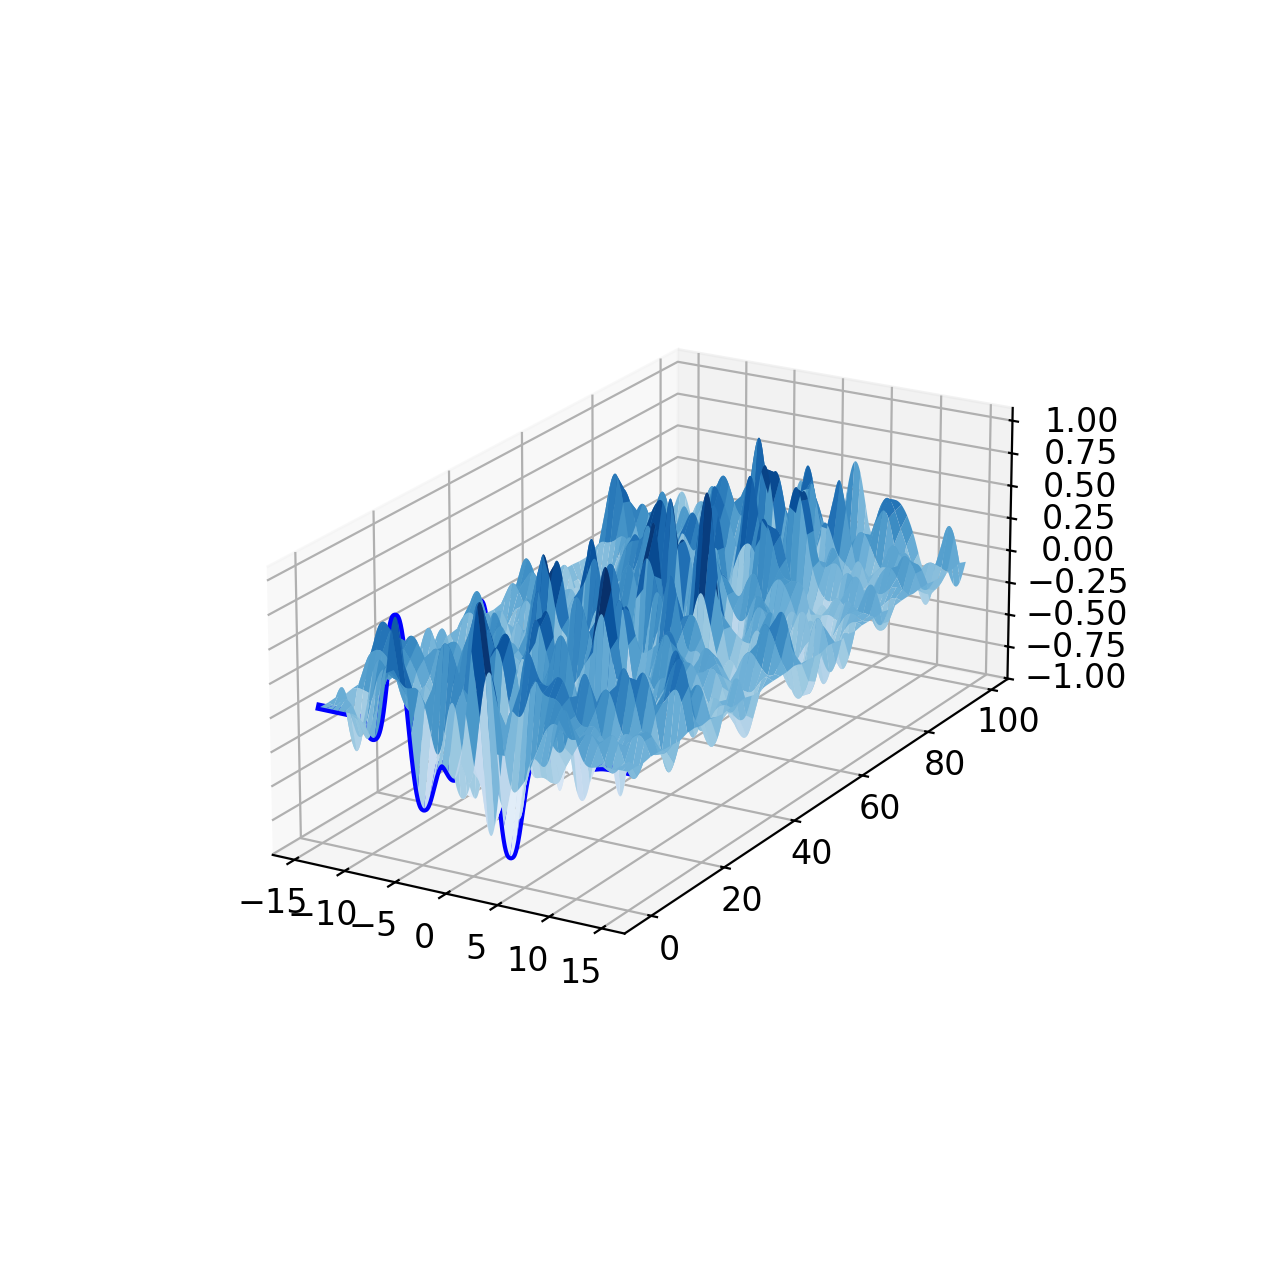

In [8]:
# Plot the data as a surface plot in time and space.
fig = plt.figure(figsize=(8, 8), dpi=200)
ax = fig.add_subplot(111, projection="3d")

# Define the space, time mesh.
xgrid, tgrid = np.meshgrid(x, t[::200])

# Make the surface plot.
ax.plot_surface(xgrid, tgrid, U[:, ::200].T, cmap="Blues")

# Plot the initial condition.
ax.plot(x, U0, zs=0, zdir="y", c="b", lw=3)

# 3-D plot formatting.
label_size = 16
tick_size = 12
ax.view_init(elev=20, azim=-60)
# ax.set_title("u(x, t)", fontsize=label_size, x=0.7, y=0.8)
# ax.set_xlabel("x (space)", labelpad=15, fontsize=label_size)
# ax.set_ylabel("t (time)", labelpad=20, fontsize=label_size)
ax.tick_params(axis="x", which="major", labelsize=tick_size)
ax.tick_params(axis="y", which="major", labelsize=tick_size)
ax.tick_params(axis="z", which="major", labelsize=tick_size, pad=15)

# Stretch the time axis.
def short_proj():
    scale = np.diag([1.0, 2.0, 1.0, 1.0])
    scale /= scale.max()
    scale[3, 3] = 1.0
    return np.dot(Axes3D.get_proj(ax), scale)

ax.get_proj = short_proj
plt.show()

## Part 2b: Compute true mode contributions

Error using "true" decomposition: 0.004474236217921848


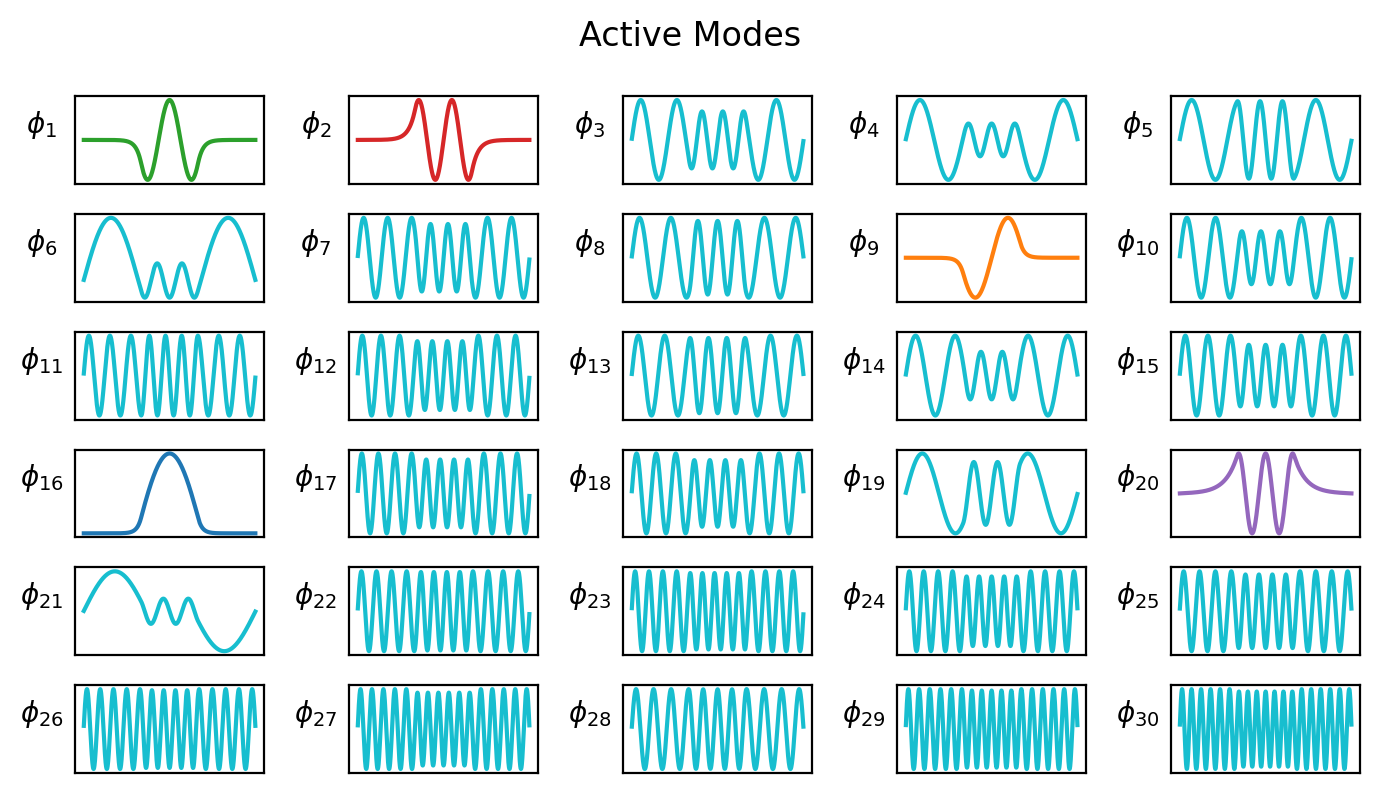

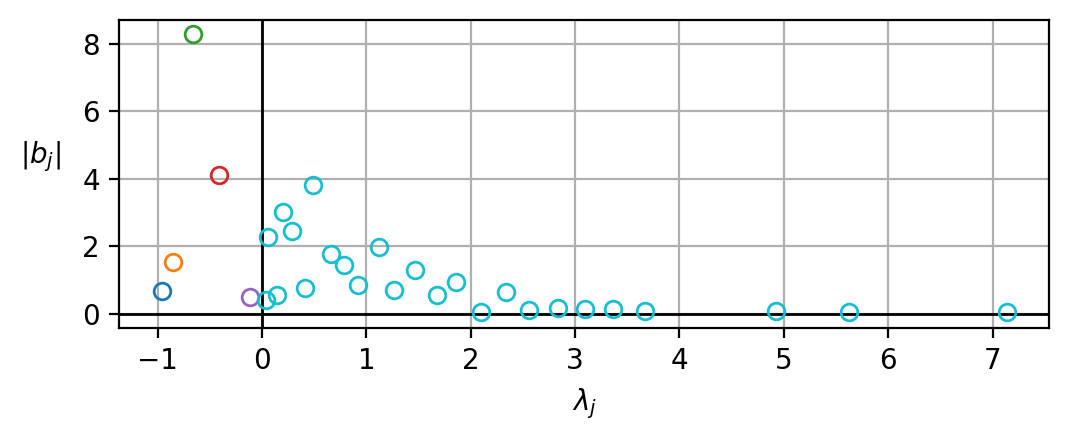

In [9]:
def sort_by_amplitude(modes, eigs, amplitudes):
    """
    Sort modes, eigenvalues, and amplitudes according to decreasing
    amplitude magnitude. Returns sorting indices and sorted metrics.
    """
    sorted_inds = np.argsort(-np.abs(amplitudes))
    sorted_modes = modes[:, sorted_inds]
    sorted_eigs = eigs[sorted_inds]
    sorted_amplitudes = amplitudes[sorted_inds]

    return sorted_inds, sorted_modes, sorted_eigs, sorted_amplitudes

# Compute the ground truth decomposition of the data.
# Note: assumes that amplitudes are constant in time (linear).
coeffs_true = np.linalg.pinv(V) @ U[:, 0]
ind_order, modes_u, eigs_u, coeffs_u = sort_by_amplitude(V, eigs_true, coeffs_true)
err = error(modes_u @ np.diag(coeffs_u) @ np.exp(np.outer(1j * eigs_u, t)), U)
print(f"Error using \"true\" decomposition: {err}")

# Plot the true modes in order of amplitude.
plt.figure(figsize=(7, 4), dpi=200)
plt.suptitle("Active Modes")

for i, idx in enumerate(ind_order[:30]):
    # Note: idx is the mode index from the original ordered set.
    mode = modes_u[:, i]

    # Differentiate between local and global modes.
    plt.subplot(6, 5, i + 1)
    if idx < 5:
        plt.plot(x, mode, c=local_colors[idx])
    else:
        plt.plot(x, mode, c=local_colors[-1])

    plt.ylabel(f"$\phi_{{{i+1}}}$", rotation=0, labelpad=12)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

# Plot the true eigenvalues against their amplitude.
plt.figure(figsize=(6, 2), dpi=200)
plt.axhline(y=0, lw=1, c="k")
plt.axvline(x=0, lw=1, c="k")

for i, idx in enumerate(ind_order[:30]):
    if idx < 5:
        plt.plot(-eigs_u[i], np.abs(coeffs_u[i]), "o", mec=local_colors[idx], mfc="none")
    else:
        plt.plot(-eigs_u[i], np.abs(coeffs_u[i]), "o", mec=local_colors[-1], mfc="none")

plt.xlabel("$\lambda_j$")
plt.ylabel("$|b_j|$", rotation=0, labelpad=15)
plt.grid()
plt.show()

## Part 3: Apply DMD

In [10]:
# Helper function for plotting all modes of a given DMD model.
def plot_all_modes(dmd, grid=None, figsize=(14, 3)):
    """
    Helper function for plotting modes, eigenvalues, and amplitudes learned by DMD.
    """
    lead_modes, lead_eigs, lead_amps = sort_by_amplitude(dmd.modes, dmd.eigs, dmd.amplitudes)[1:]
    if grid is None:
        grid = (1, len(lead_eigs))
    plt.figure(figsize=figsize, dpi=150)
    for i, (eig, mode, b) in enumerate(zip(lead_eigs, lead_modes.T, lead_amps)):
        plt.subplot(grid[0], grid[1], i + 1)
        plt.plot(mode, c="k")
        plt.title(f"λ{i + 1} = {np.round(eig, decimals=4)}\nb{i + 1} = {np.round(b, decimals=4)}")
        plt.xlabel("x")
    plt.tight_layout()
    plt.show()

# Define the data to be passed to DMD.
X_dmd = U[:, ::100]
t_dmd = t[::100]
print(f"DMD data dimensions in (space, time): {X_dmd.shape}")
print(f"DMD time step: dt = {np.round(t_dmd[1] - t_dmd[0], decimals=3)}")

DMD data dimensions in (space, time): (1000, 100)
DMD time step: dt = 1.0


### Optimized DMD

OptDMD Error = 0.19461425833520424


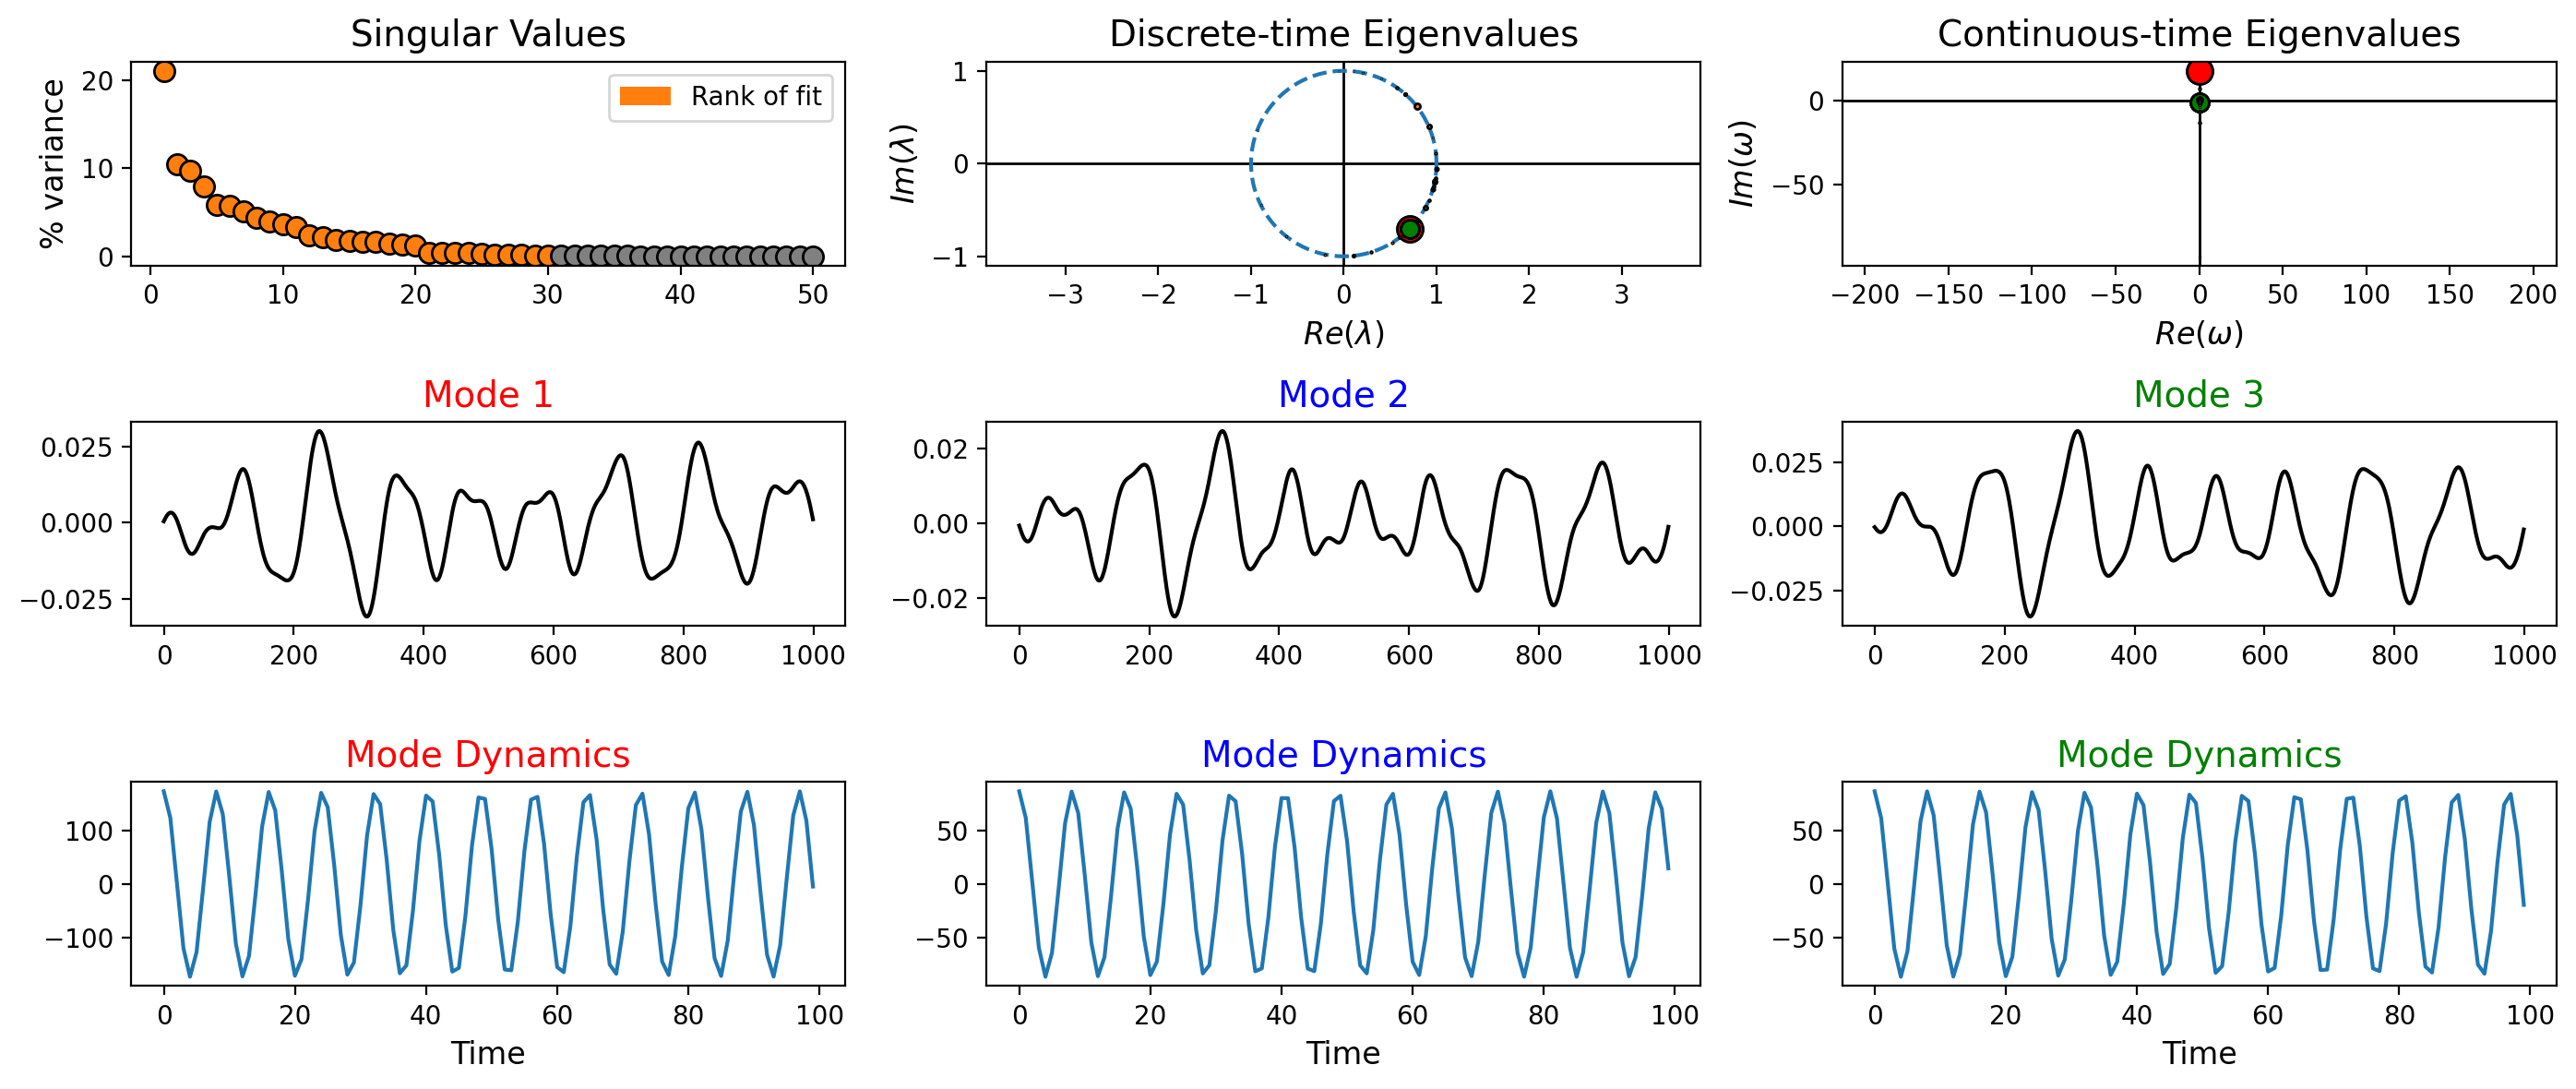

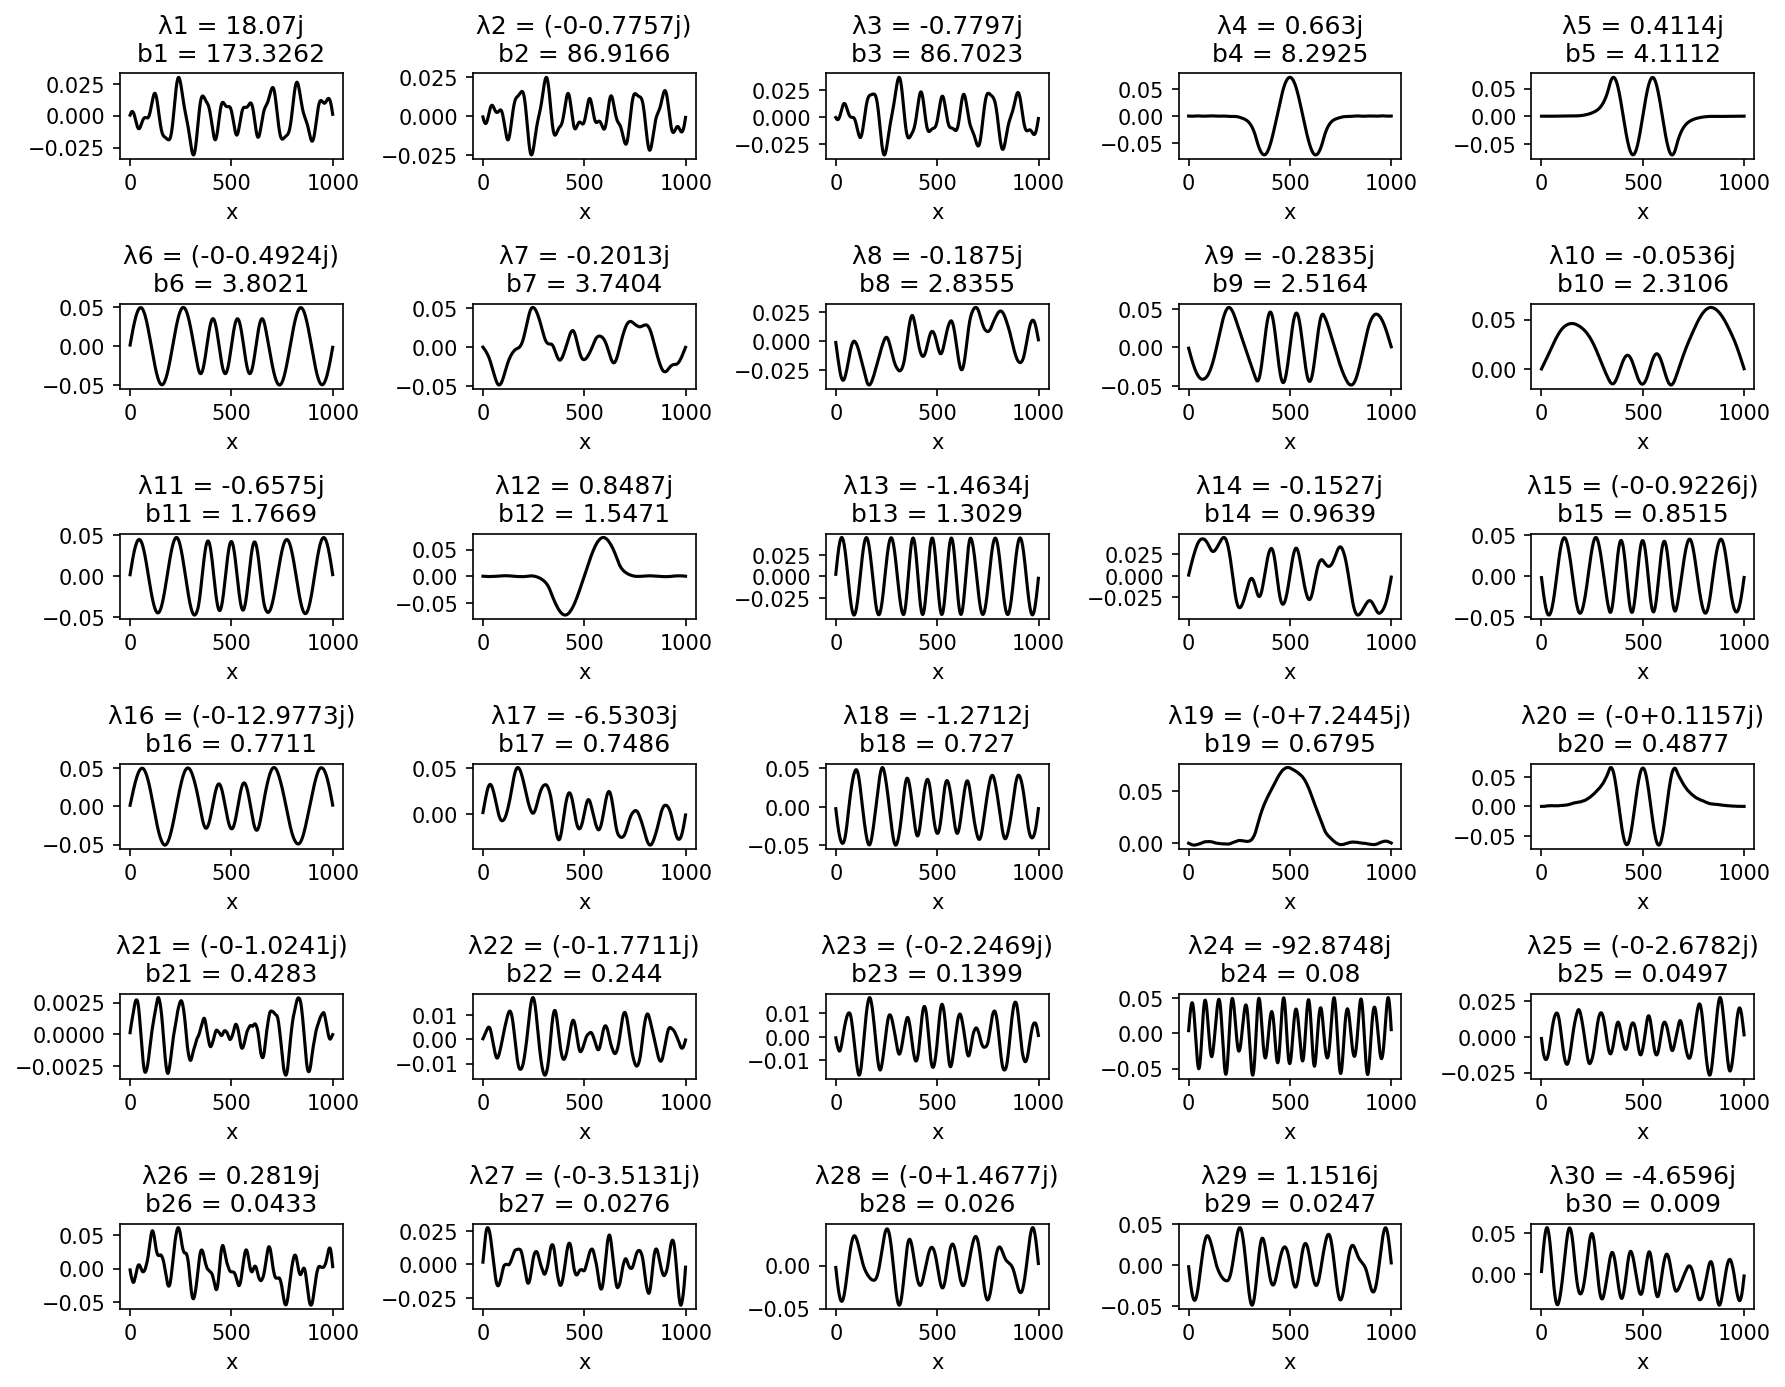

In [11]:
optdmd = BOPDMD(svd_rank=30)
optdmd.fit(X_dmd, t_dmd)

print(f"OptDMD Error = {error(optdmd.reconstructed_data, X_dmd)}")
plot_summary(optdmd, figsize=(14, 6))
plot_all_modes(optdmd, grid=(8, 5), figsize=(12, 12))

### Sparse-mode DMD (SR3)

Sparse-mode DMD Error = 0.11218933808769815


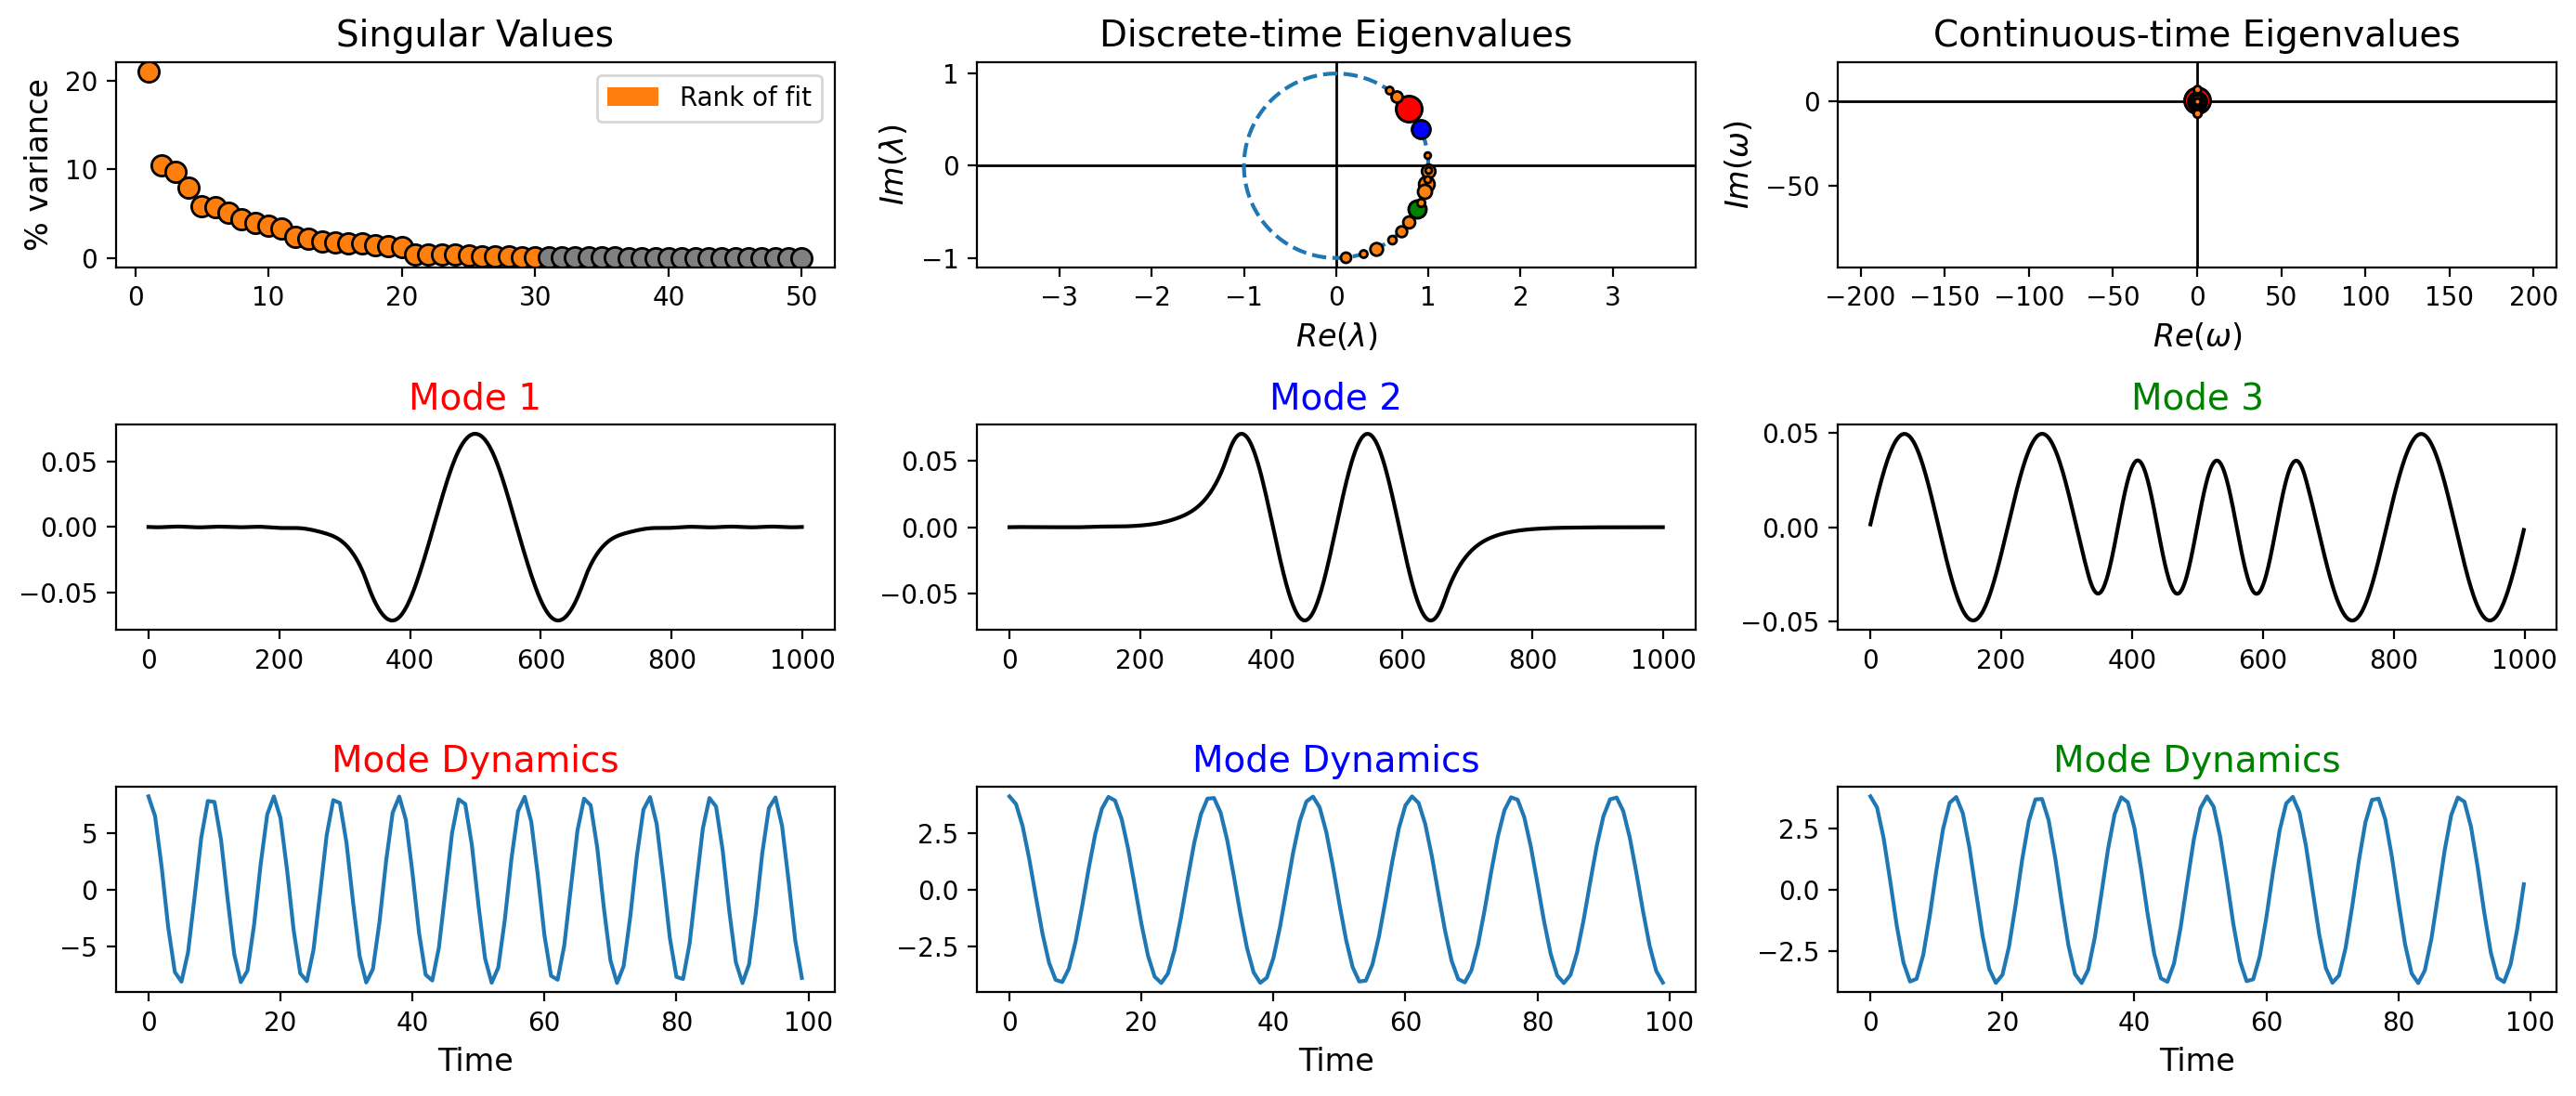

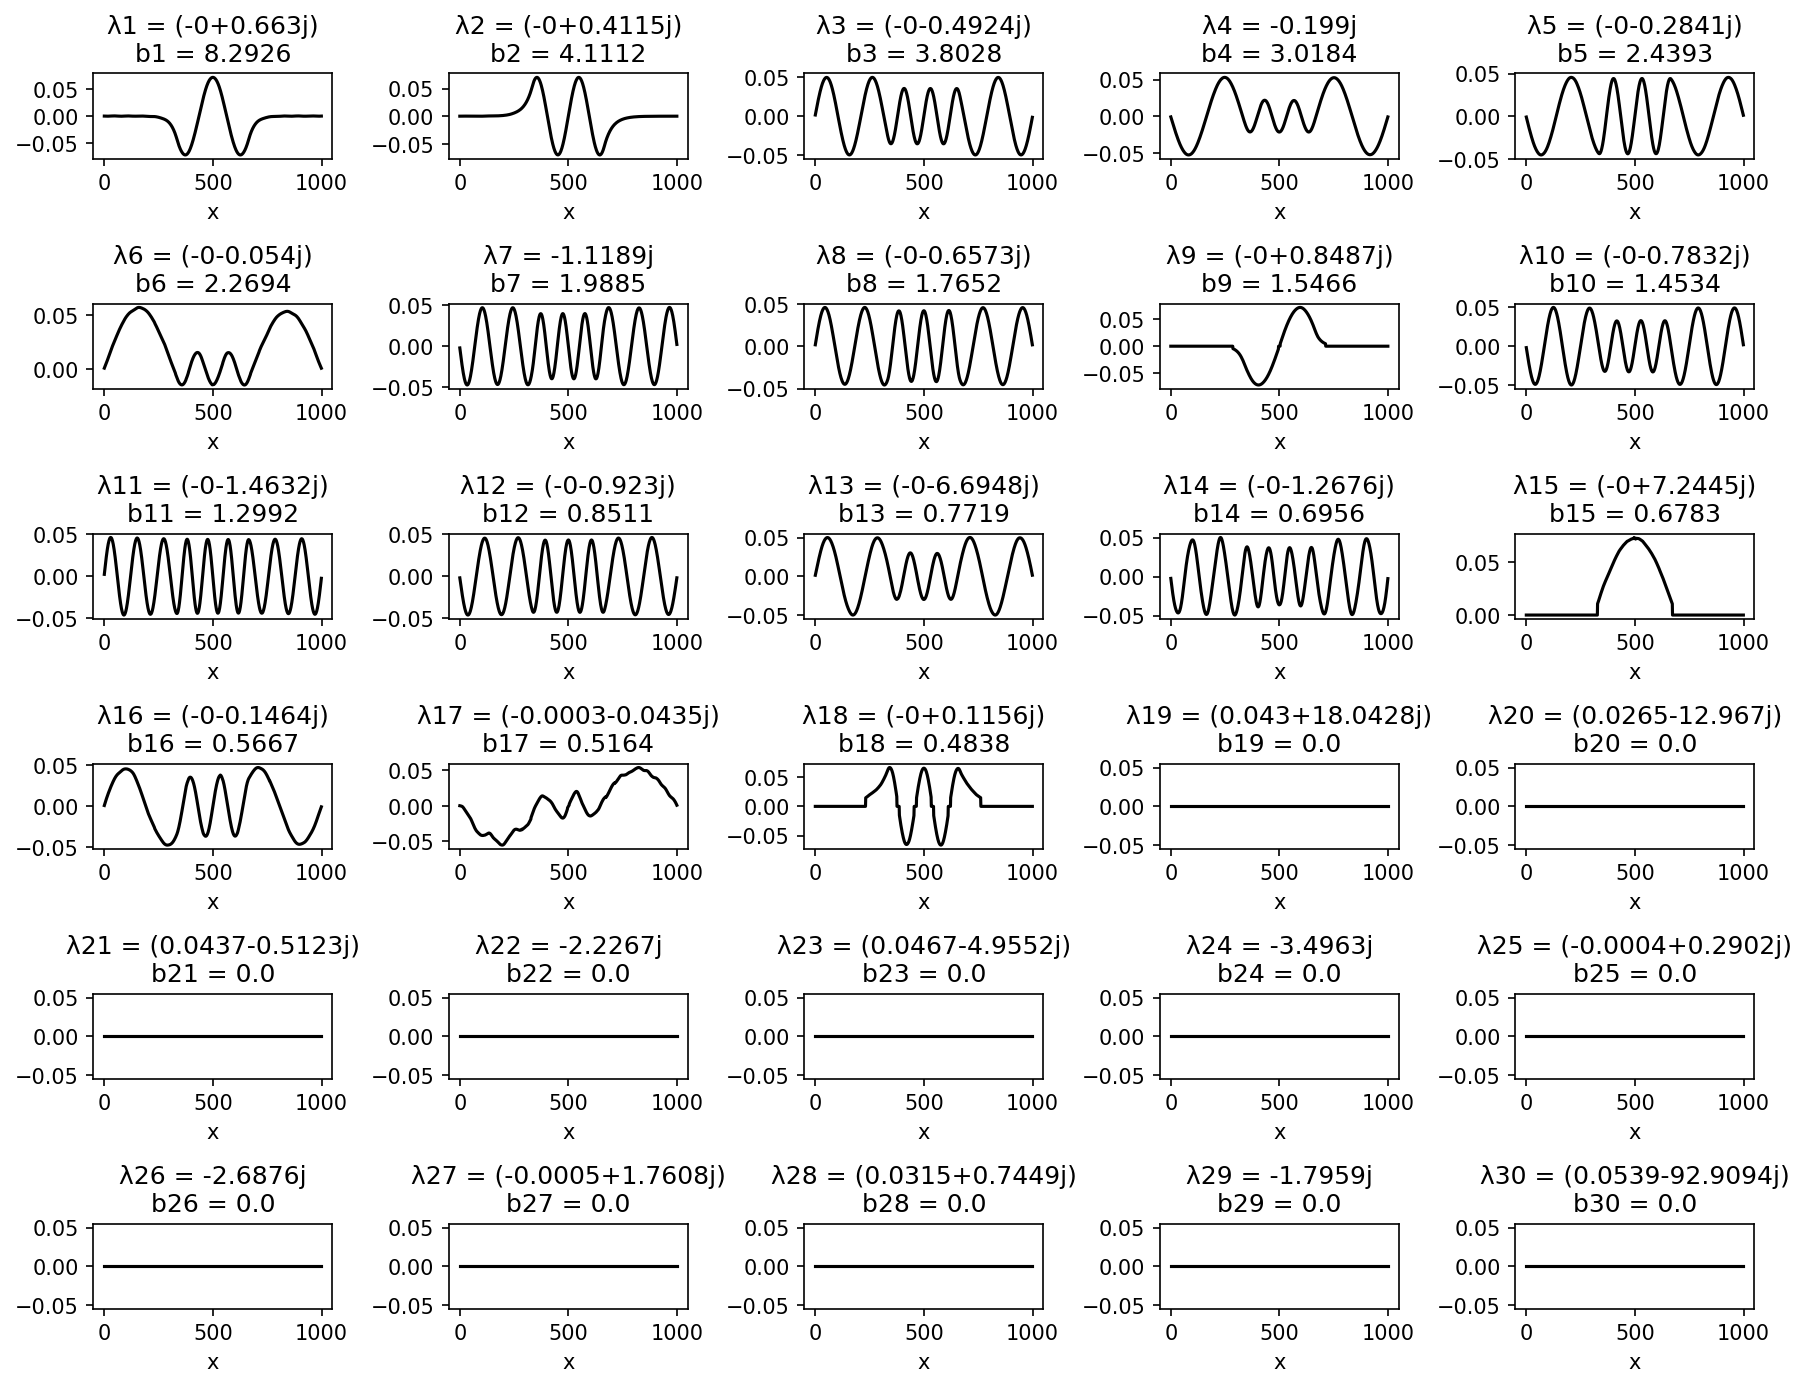

In [12]:
sp_optdmd_sr3 = SparseBOPDMD(
    svd_rank=30,
    SR3_step=1,
    mode_regularizer="l1",
    regularizer_params={"lambda": 0.007},
    apply_debias=True,
    index_global="auto",
    varpro_opts_dict={
        "global_mode_params": {"active_thresh": 0.02, "global_thresh": 0.5}
    },
)
sp_optdmd_sr3.fit(X_dmd, t_dmd)

print(f"Sparse-mode DMD Error = {error(sp_optdmd_sr3.reconstructed_data, X_dmd)}")
plot_summary(sp_optdmd_sr3, figsize=(14, 6))
plot_all_modes(sp_optdmd_sr3, grid=(8, 5), figsize=(12, 12))

### Figure creation code:

In [13]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from matplotlib.lines import Line2D

def generate_mode_figure(
    title, # plot suptitle
    label, # amplitude plot label
    modes, # modes, stored by column (not ordered)
    eigs, # eigenvalues (not ordered)
    amplitudes, # amplitudes (not ordered)
    idx_local, # idx_local[i] = index where local mode i is located
    idx_flip=None, # idx_flip[i] = index where the mode sign should be flipped
    xlim=(-2.2, 8.2), # choose xlim of amplitude plot
    ylim=(-0.8, 8.8), # choose ylim of amplitude plot
    marker_style="o", # marker style for amplitude plot
    plot_truth=False, # whether or not to add plot of true amplitudes
):
    # Start by sorting the DMD modes by amplitude.
    modes, eigs, amplitudes = sort_by_amplitude(modes, eigs, amplitudes)[1:]

    # Flip mode signs for plotting.
    modes = flip_mode_signs(modes)
    if idx_flip:
        modes[:, idx_flip] = -modes[:, idx_flip]

    fig = plt.figure(figsize=(5, 4.5), dpi=200)
    fig.suptitle(title)

    # Plot a 5x4 grid of the 20 leading modes.
    gs = gridspec.GridSpec(9, 4)
    modes_axes = []
    for i in range(5):
        for j in range(4):
            modes_axes.append(fig.add_subplot(gs[i, j]))

    # Plot eigenvalues vs. amplitudes below.
    amplitude_ax = fig.add_subplot(gs[-4:, :])

    # Plot the leading 20 modes.
    for i, ax in enumerate(modes_axes):
        if i in idx_local:
            color = local_colors[idx_local.index(i)]
        else:
            color = local_colors[-1]

        ax.axhline(y=0, c="gray", lw=0.5)
        ax.axvline(x=0, c="gray", lw=0.5)
        ax.plot(x, modes[:, i], c=color)
        ax.set_ylabel(f"$\phi_{{{i+1}}}$", rotation=0, labelpad=12)
        ax.set_xticks([])
        ax.set_yticks([])

    # Plot eigenvalues vs. amplitudes.
    amplitude_ax.axhline(y=0, lw=0.8, c="k")
    amplitude_ax.axvline(x=0, lw=0.8, c="k")

    if plot_truth:
        for i, idx in enumerate(ind_order):
            color = local_colors[min(idx, 5)]
            amplitude_ax.plot(-eigs_u[i], np.abs(coeffs_u[i]), "o", mec=color, mfc="none", alpha=0.4)
        amplitude_ax.plot([], [], "o", mec="k", mfc="none", label="Truth") # for legend

    for i in range(len(eigs)):
        if i in idx_local:
            color = local_colors[idx_local.index(i)]
        else:
            color = local_colors[-1]

        amplitude_ax.plot(-eigs[i], np.abs(amplitudes[i]), marker_style, mec=color, mfc="none")

    amplitude_ax.plot([], [], marker_style, mec="k", mfc="none", label=label) # for legend
    amplitude_ax.set_xlabel("$\lambda_j$")
    amplitude_ax.set_ylabel("$|b_j|$", rotation=0, labelpad=12)
    amplitude_ax.set_xlim(xlim)
    amplitude_ax.set_ylim(ylim)
    amplitude_ax.grid()
    plt.legend()

    # Set finer tick labels for the default xticks.
    if xlim == (-2.2, 8.2):
        amplitude_ax.set_xticks(np.arange(-2, 9))
        amplitude_ax.set_xticklabels([str(i) for i in np.arange(-2, 9)])

    plt.tight_layout()
    plt.show()

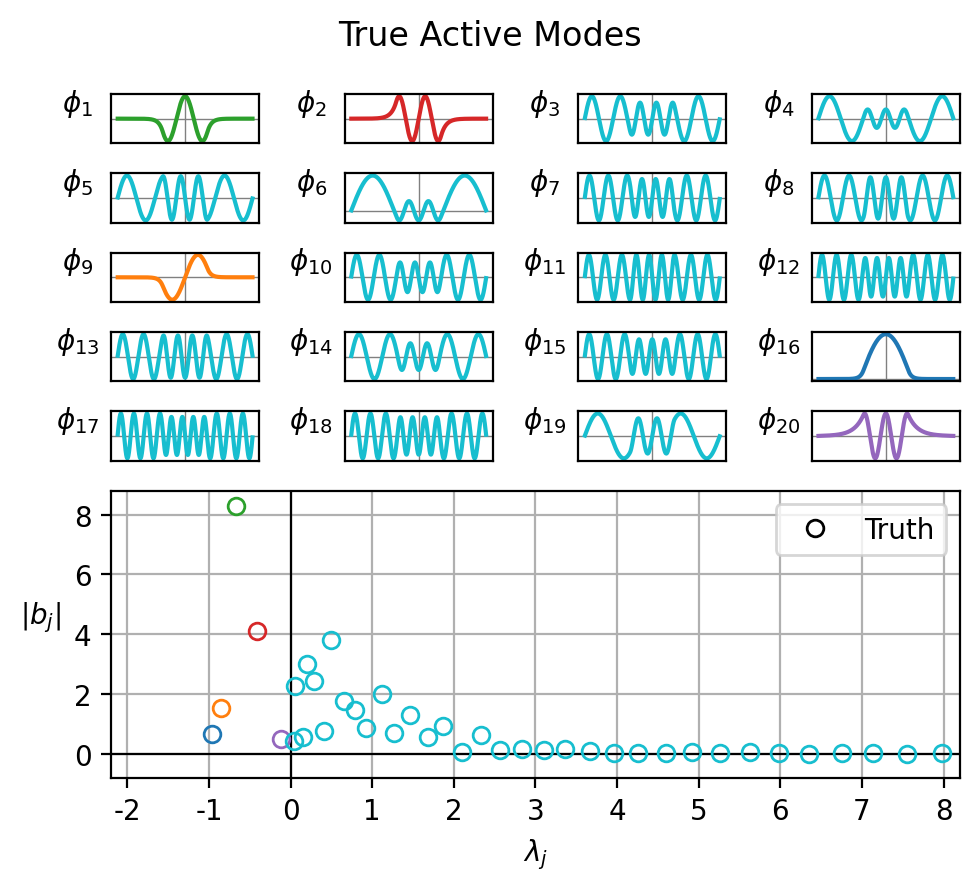

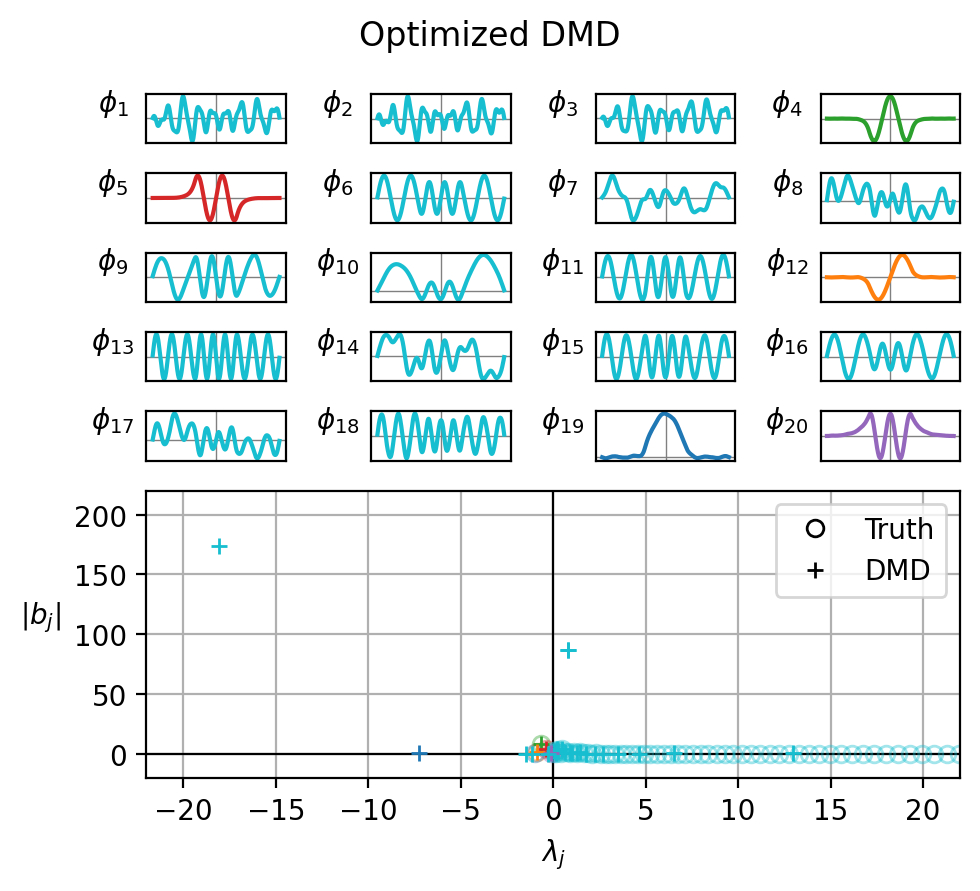

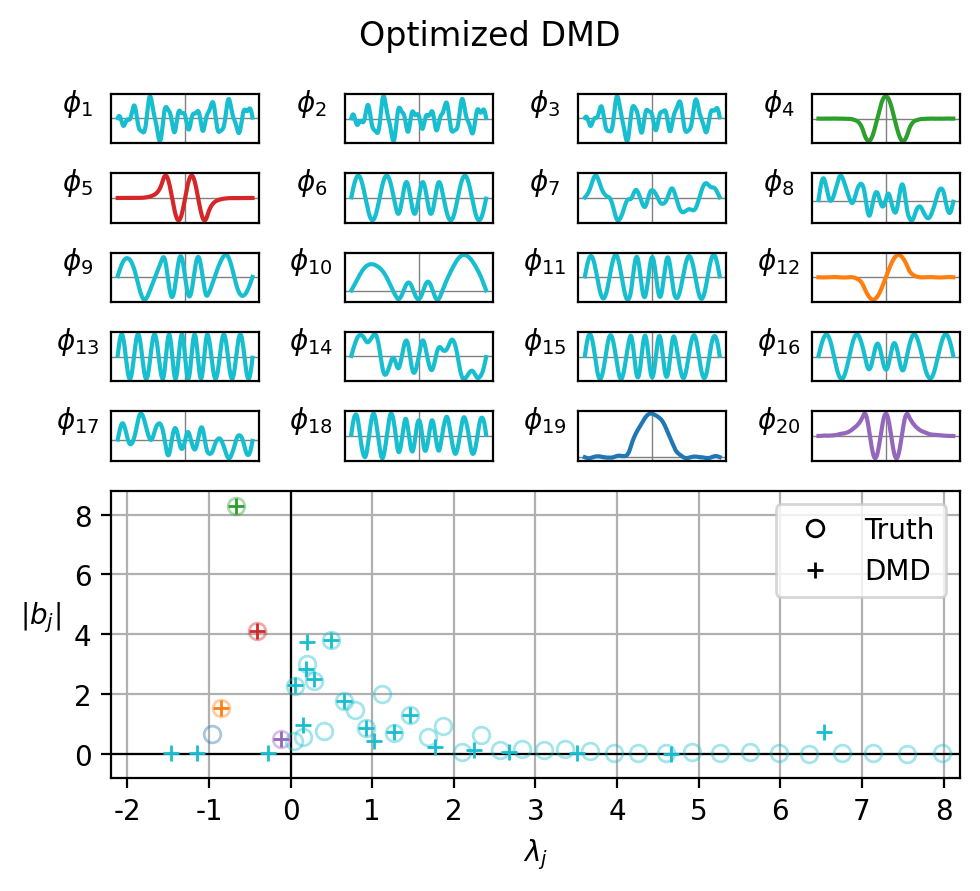

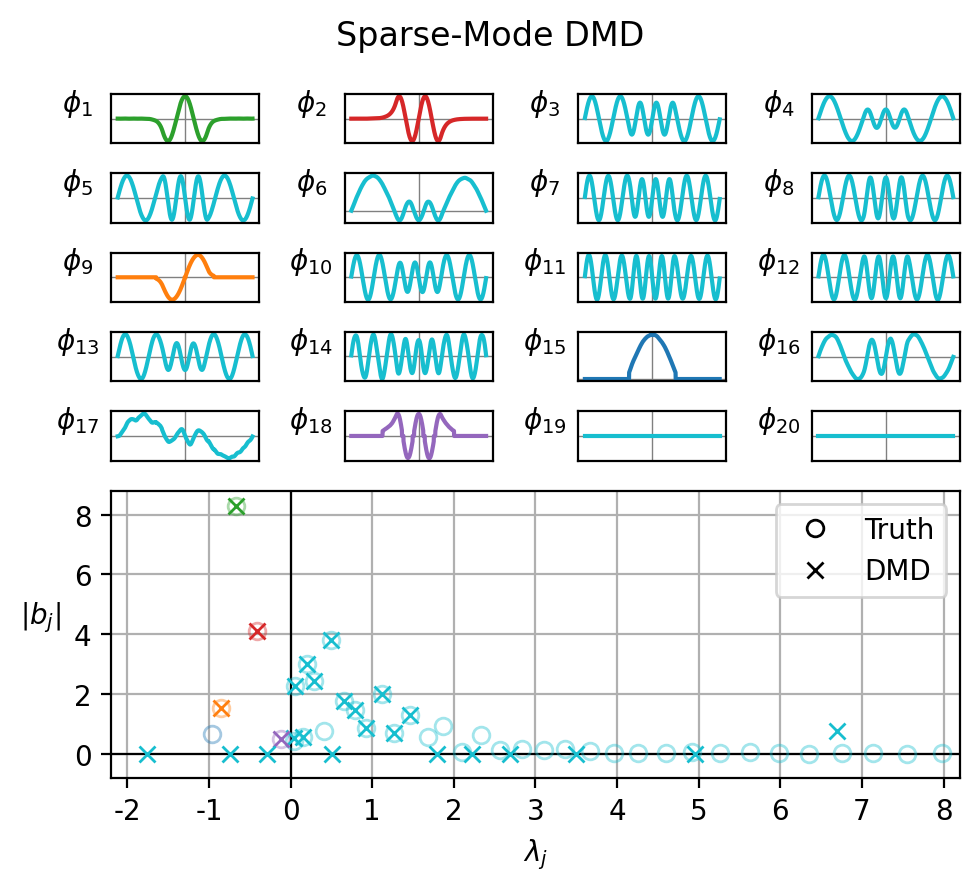

In [14]:
# (1) True Modes.
generate_mode_figure(
    title="True Active Modes",
    label="Truth",
    modes=V,
    eigs=eigs_true,
    amplitudes=coeffs_true,
    idx_local=[15, 8, 0, 1, 19],
    idx_flip=[0, 8],
)

# (2a) Optimized DMD Modes (with large amplitudes).
generate_mode_figure(
    title="Optimized DMD",
    label="DMD",
    modes=optdmd.modes,
    eigs=optdmd.eigs.imag,
    amplitudes=optdmd.amplitudes,
    idx_local=[18, 11, 3, 4, 19],
    idx_flip=[3, 11, 18],
    marker_style="+",
    plot_truth=True,
    xlim=[-22, 22],
    ylim=[-20, 220],
)
# (2b) Optimized DMD Modes (remove large amplitudes).
generate_mode_figure(
    title="Optimized DMD",
    label="DMD",
    modes=optdmd.modes,
    eigs=optdmd.eigs.imag,
    amplitudes=optdmd.amplitudes,
    idx_local=[18, 11, 3, 4, 19],
    idx_flip=[3, 11, 18],
    marker_style="+",
    plot_truth=True,
)

# (3) Sparse-Mode DMD Modes.
generate_mode_figure(
    title="Sparse-Mode DMD",
    label="DMD",
    modes=sp_optdmd_sr3.modes,
    eigs=sp_optdmd_sr3.eigs.imag,
    amplitudes=sp_optdmd_sr3.amplitudes,
    idx_local=[14, 8, 0, 1, 17],
    idx_flip=[0, 8],
    marker_style="x",
    plot_truth=True,
)

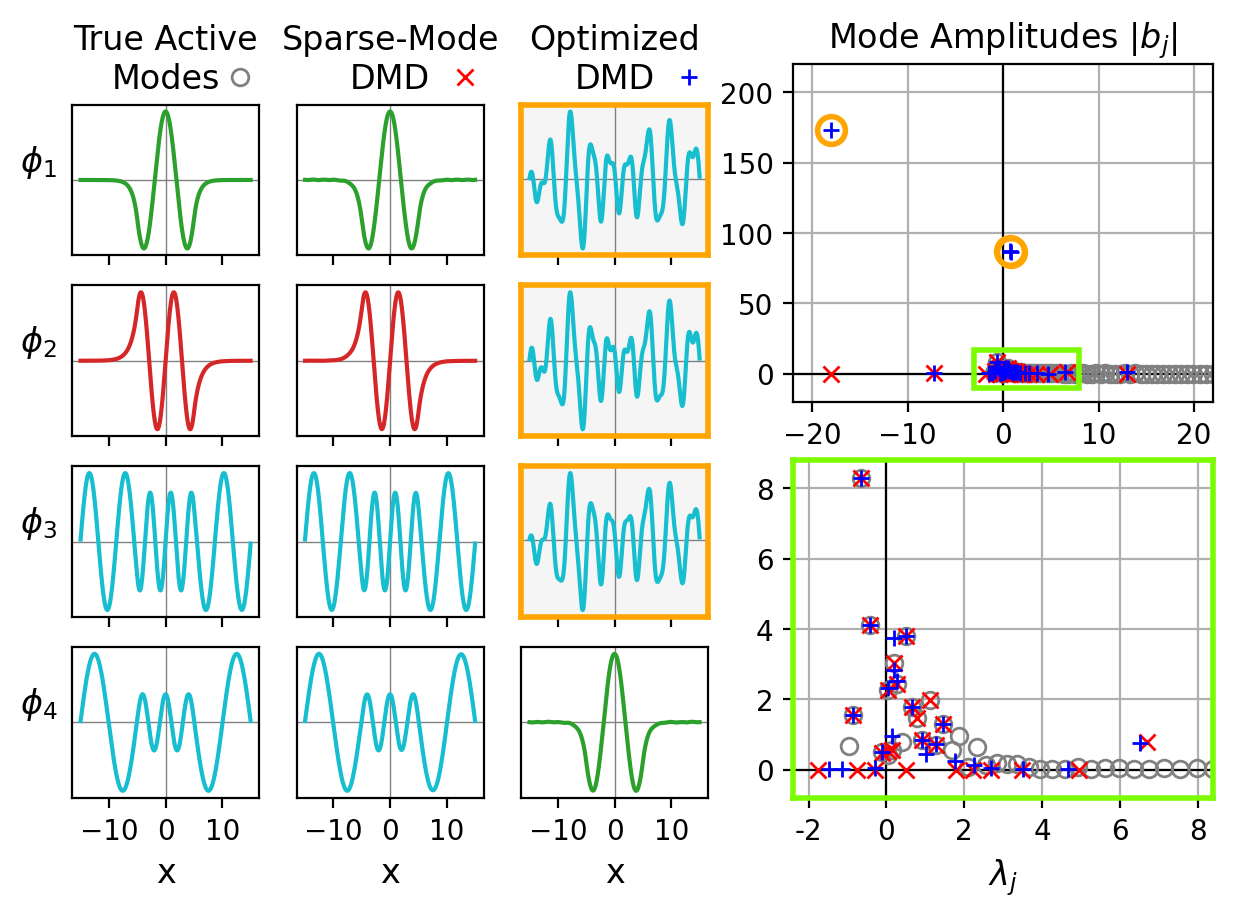

In [15]:
all_titles = ["True Active\nModes", "Sparse-Mode\nDMD", "Optimized\nDMD"]
all_labels = ["Truth", "Sparse-Mode", "Optimized"]
all_modes = [V, sp_optdmd_sr3.modes, optdmd.modes]
all_eigs = [eigs_true, sp_optdmd_sr3.eigs.imag, optdmd.eigs.imag]
all_amps = [coeffs_true, sp_optdmd_sr3.amplitudes, optdmd.amplitudes]
all_colors = ["gray", "r", "b"]
all_markers = ["o", "x", "+"]
all_idx_local = [
    [15, 8, 0, 1, 19],
    [14, 8, 0, 1, 17],
    [18, 11, 3, 4, 19],
]
all_idx_flip = [[0, 8], [0, 8], [3, 11, 18]]

# Plot a 4x3 grid of the 4 leading modes (truth, sparse, opt).
fig = plt.figure(figsize=(7, 4.5), dpi=200)
gs = gridspec.GridSpec(4, 5)

# Plot eigenvalues vs. amplitudes to the right.
amplitude_ax1 = fig.add_subplot(gs[:2, 3:])
amplitude_ax2 = fig.add_subplot(gs[2:, 3:])
amplitude_ax1.set_position([0.64, 0.55, 0.3, 0.375])
amplitude_ax2.set_position([0.64, 0.11, 0.3, 0.375])

for ax in [amplitude_ax1, amplitude_ax2]:
    ax.axhline(y=0, lw=0.8, c="k")
    ax.axvline(x=0, lw=0.8, c="k")
    ax.grid()

# j indexes truth, sparse, opt.
for j in range(3):
    # Start by sorting the DMD modes by amplitude.
    modes, eigs, amplitudes = all_modes[j], all_eigs[j], all_amps[j]
    modes, eigs, amplitudes = sort_by_amplitude(modes, eigs, amplitudes)[1:]
    modes = flip_mode_signs(modes)
    modes[:, all_idx_flip[j]] = -modes[:, all_idx_flip[j]]

    # i indexes mode indices.
    for i in range(4):
        if i in all_idx_local[j]:
            color = local_colors[all_idx_local[j].index(i)]
        else:
            color = local_colors[-1]

        ax = fig.add_subplot(gs[i, j])
        ax.axhline(y=0, c="gray", lw=0.5)
        ax.axvline(x=0, c="gray", lw=0.5)
        ax.plot(x, modes[:, i], c=color)
        ax.set_yticks([])

        if i == 0:
            # For top row, add titles and legend markers.
            ax.set_title(all_titles[j])
            ax.legend(
                handles=[
                    Line2D(
                        [], [],
                        marker=all_markers[j],
                        color=all_colors[j],
                        linestyle="none",
                        mfc="none",
                    ),
                ],
                bbox_to_anchor=(1.3, 1.43),
                loc="upper right",
                frameon=False,
            )

        if j == 0:
            # For left column, add mode labels.
            ax.set_ylabel(f"$\phi_{{{i+1}}}$", rotation=0, labelpad=12, fontsize=12)

        elif j == 2 and i < 3:
            # For last column, mark the spurious modes.
            ax.set_facecolor("whitesmoke")
            for spine in ax.spines.values():
                spine.set_edgecolor("orange")
                spine.set_linewidth(2.0)

        if i == 3:
            ax.set_xlabel("x", fontsize=12)
        else:
            ax.set_xticklabels([])

    # Plot eigenvalues vs. amplitudes.
    for ax in [amplitude_ax1, amplitude_ax2]:
        ax.plot(
            -eigs,
            np.abs(amplitudes),
            all_markers[j],
            mec=all_colors[j],
            mfc="none",
        )

    # Mark spurious eigenvalues.
    if j == 2:
        amplitude_ax1.plot(
            -eigs[:3],
            np.abs(amplitudes)[:3],
            "o",
            ms=10,
            mfc="none",
            color="orange",
            markeredgewidth=2,
        )

amplitude_ax1.set_title("Mode Amplitudes $|b_j|$")
amplitude_ax1.set_xlim([-22, 22])
amplitude_ax1.set_ylim([-20, 220])
amplitude_ax1.add_patch(
    patches.Rectangle(
        (-3, -10), 11, 27, 
        linewidth=2,
        edgecolor="lawngreen",
        facecolor="none",
        zorder=10,
    )
)
amplitude_ax2.set_xlabel("$\lambda_j$", fontsize=12)
amplitude_ax2.set_xlim([-2.4, 8.4])
amplitude_ax2.set_ylim([-0.8, 8.8])
amplitude_ax2.set_xticks(np.arange(-2, 9, 2))
amplitude_ax2.set_xticklabels([str(i) for i in np.arange(-2, 9, 2)])
for spine in amplitude_ax2.spines.values():
    spine.set_edgecolor("lawngreen")
    spine.set_linewidth(2.0)

# plt.tight_layout()
plt.show()